In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [6]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [7]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [8]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# 3. Изменение порядка предложений

In [9]:
c2 = pd.read_csv('c2_augmented_3.csv')
model, val_dataset, train_time = fit(c2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you exp

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.025517,0.941913
2,0.533901,0.972530
3,0.157304,1.306623


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено за 316.97 секунд (0:05:16)


In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6307
F1 Micro: 0.6307
F1 Macro: 0.5883
F1 Weighted: 0.6262
MAE: 0.4437
              precision    recall  f1-score   support

           1       0.92      0.50      0.65       153
           2       0.53      0.78      0.63       227
           3       0.61      0.75      0.67       475
           4       0.68      0.50      0.58       343
           5       0.69      0.58      0.63       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.74      0.56      0.59      1465
weighted avg       0.66      0.63      0.63      1465



0.6307
0.6307
0.5883
0.6262
0.4437
316.97


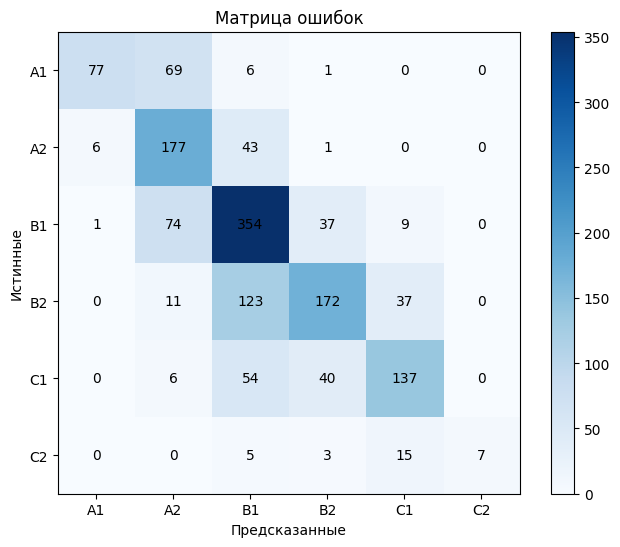

In [17]:
visualize_cm(true_labels, predictions)

# 4. Реорганизация фраз

In [18]:
c2 = pd.read_csv('c2_augmented_4.csv')
model, val_dataset, train_time = fit(c2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you exp

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.996105,0.898378
2,0.472593,0.992608
3,0.116990,1.415182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено за 317.71 секунд (0:05:17)


In [19]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6478
F1 Micro: 0.6478
F1 Macro: 0.6227
F1 Weighted: 0.6466
MAE: 0.4280
              precision    recall  f1-score   support

           1       0.85      0.57      0.68       153
           2       0.57      0.67      0.62       227
           3       0.62      0.74      0.67       475
           4       0.68      0.57      0.62       343
           5       0.68      0.63      0.66       237
           6       0.91      0.33      0.49        30

    accuracy                           0.65      1465
   macro avg       0.72      0.59      0.62      1465
weighted avg       0.66      0.65      0.65      1465



0.6478
0.6478
0.6227
0.6466
0.4280
317.71


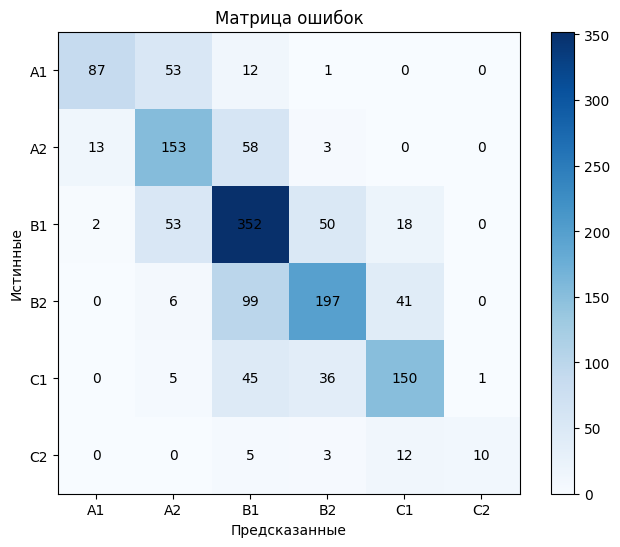

In [20]:
visualize_cm(true_labels, predictions)

# 5. Усложнение объяснений

In [21]:
c2 = pd.read_csv('c2_augmented_5.csv')
model, val_dataset, train_time = fit(c2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you exp

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.995181,0.920211
2,0.497755,1.002106
3,0.107456,1.378701


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено за 318.23 секунд (0:05:18)


In [22]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6389
F1 Micro: 0.6389
F1 Macro: 0.5691
F1 Weighted: 0.6346
MAE: 0.4369
              precision    recall  f1-score   support

           1       0.87      0.58      0.70       153
           2       0.56      0.74      0.64       227
           3       0.62      0.72      0.67       475
           4       0.63      0.58      0.60       343
           5       0.69      0.57      0.63       237
           6       1.00      0.10      0.18        30

    accuracy                           0.64      1465
   macro avg       0.73      0.55      0.57      1465
weighted avg       0.66      0.64      0.63      1465



0.6389
0.6389
0.5691
0.6346
0.4369
318.23


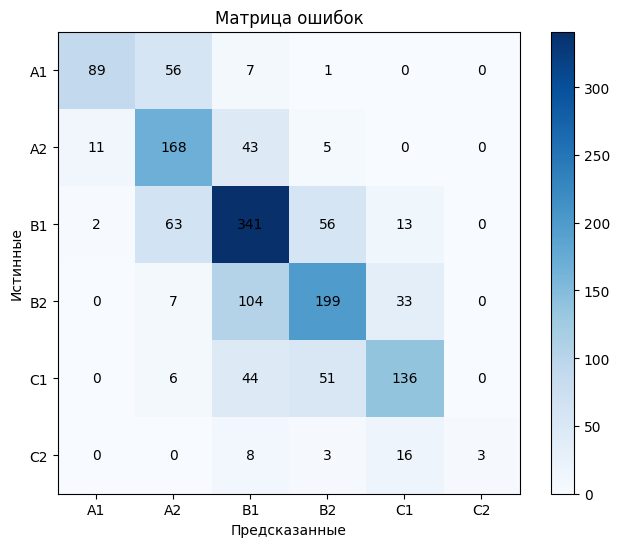

In [23]:
visualize_cm(true_labels, predictions)

# 8. Использованеи аналогий

In [25]:
c2 = pd.read_csv('c2_augmented_8.csv')
model, val_dataset, train_time = fit(c2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you exp

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.008691,0.912351
2,0.497462,0.963702
3,0.125858,1.382777


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено за 318.19 секунд (0:05:18)


In [26]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6444
F1 Micro: 0.6444
F1 Macro: 0.5965
F1 Weighted: 0.6413
MAE: 0.4375
              precision    recall  f1-score   support

           1       0.86      0.59      0.70       153
           2       0.56      0.74      0.64       227
           3       0.62      0.73      0.67       475
           4       0.67      0.55      0.60       343
           5       0.68      0.61      0.64       237
           6       0.86      0.20      0.32        30

    accuracy                           0.64      1465
   macro avg       0.71      0.57      0.60      1465
weighted avg       0.66      0.64      0.64      1465



0.6444
0.6444
0.5965
0.6413
0.4375
318.19


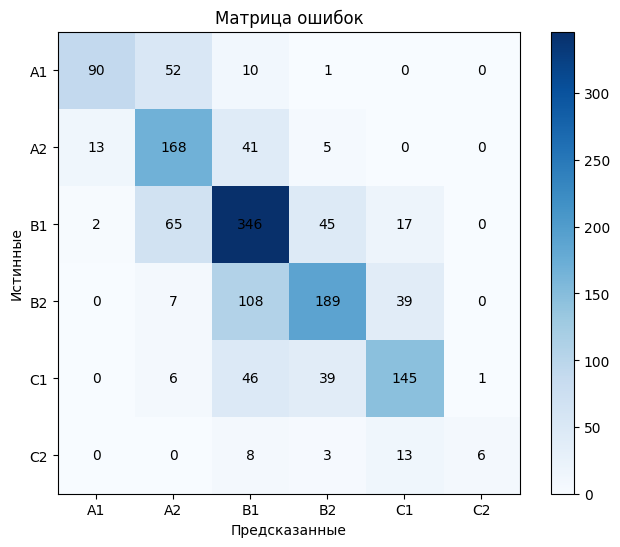

In [27]:
visualize_cm(true_labels, predictions)

# 9. Синтаксические трансформации

In [28]:
c2 = pd.read_csv('c2_augmented_9.csv')
model, val_dataset, train_time = fit(c2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you exp

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.992253,0.901441
2,0.473459,0.989071
3,0.140017,1.405599


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено за 317.59 секунд (0:05:17)


In [29]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6471
F1 Micro: 0.6471
F1 Macro: 0.6212
F1 Weighted: 0.6451
MAE: 0.4253
              precision    recall  f1-score   support

           1       0.88      0.52      0.66       153
           2       0.57      0.70      0.63       227
           3       0.63      0.74      0.68       475
           4       0.66      0.57      0.61       343
           5       0.67      0.63      0.65       237
           6       1.00      0.33      0.50        30

    accuracy                           0.65      1465
   macro avg       0.73      0.58      0.62      1465
weighted avg       0.67      0.65      0.65      1465



0.6471
0.6471
0.6212
0.6451
0.4253
317.59


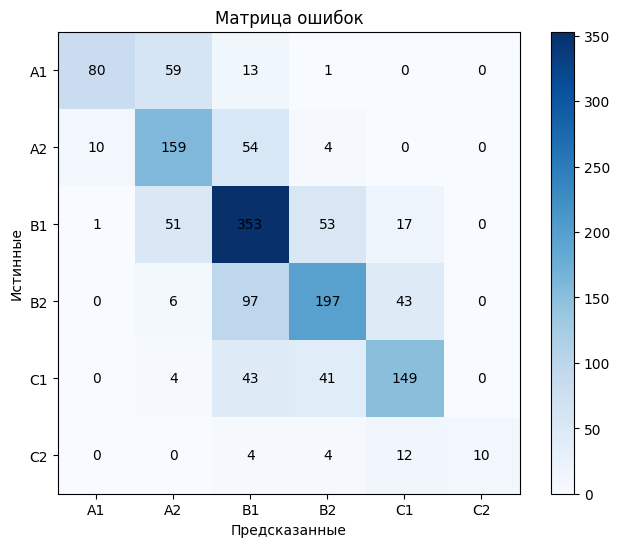

In [30]:
visualize_cm(true_labels, predictions)

# 11. Перефразирование

In [31]:
c2 = pd.read_csv('c2_augmented_11.csv')
model, val_dataset, train_time = fit(c2)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you exp

Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.996038,0.911799
2,0.483042,0.980978
3,0.130856,1.379159


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено за 317.80 секунд (0:05:17)


In [32]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6519
F1 Micro: 0.6519
F1 Macro: 0.6292
F1 Weighted: 0.6503
MAE: 0.4191
              precision    recall  f1-score   support

           1       0.87      0.55      0.67       153
           2       0.57      0.74      0.64       227
           3       0.63      0.74      0.68       475
           4       0.67      0.57      0.62       343
           5       0.69      0.62      0.65       237
           6       0.85      0.37      0.51        30

    accuracy                           0.65      1465
   macro avg       0.71      0.60      0.63      1465
weighted avg       0.67      0.65      0.65      1465



0.6519
0.6519
0.6292
0.6503
0.4191
317.80


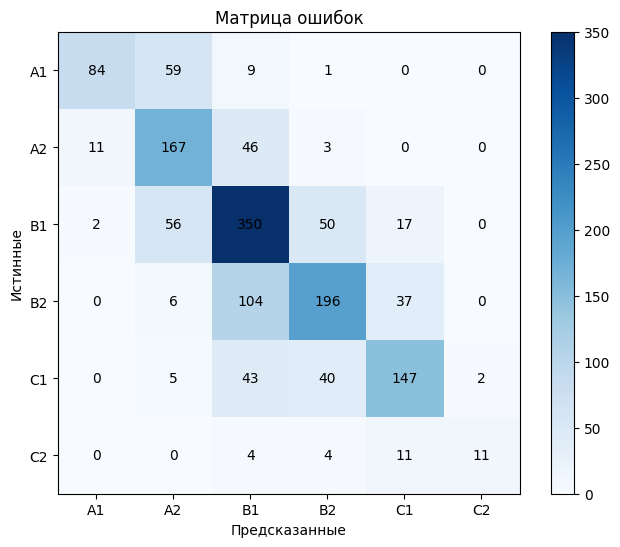

In [33]:
visualize_cm(true_labels, predictions)

# Генерация с примером

In [9]:
c2 = pd.read_csv('c2_generated_with_example_llama3.csv')
c2.rename(columns={"generated-text": "augmented-text"}, inplace=True)
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.040200,0.953138
2,0.569700,1.010846
3,0.157900,1.404335


Обучение завершено за 322.45 секунд (0:05:22)


In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6218
F1 Micro: 0.6218
F1 Macro: 0.5662
F1 Weighted: 0.6177
MAE: 0.4512
              precision    recall  f1-score   support

           1       0.92      0.43      0.59       153
           2       0.52      0.70      0.60       227
           3       0.62      0.71      0.66       475
           4       0.64      0.55      0.59       343
           5       0.63      0.65      0.64       237
           6       0.75      0.20      0.32        30

    accuracy                           0.62      1465
   macro avg       0.68      0.54      0.57      1465
weighted avg       0.65      0.62      0.62      1465



0.6218
0.6218
0.5662
0.6177
0.4512
322.45


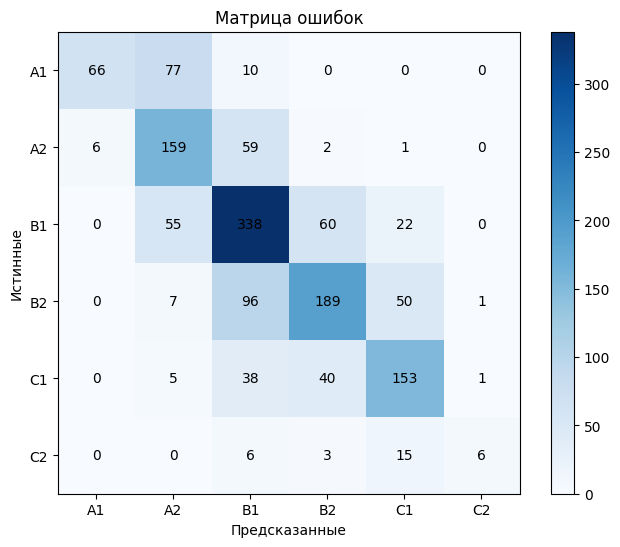

In [11]:
visualize_cm(true_labels, predictions)

# Генерация без примера

In [12]:
c2 = pd.read_csv('c2_generated_llama3.csv')
c2.rename(columns={"generated-text": "augmented-text"}, inplace=True)
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.027600,0.944546
2,0.532800,1.028162
3,0.139500,1.457336


Обучение завершено за 327.75 секунд (0:05:27)


In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time) 

Accuracy: 0.6212
F1 Micro: 0.6212
F1 Macro: 0.5263
F1 Weighted: 0.6146
MAE: 0.4457
              precision    recall  f1-score   support

           1       0.91      0.45      0.60       153
           2       0.53      0.75      0.62       227
           3       0.64      0.69      0.67       475
           4       0.60      0.59      0.60       343
           5       0.64      0.58      0.61       237
           6       0.50      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.64      0.52      0.53      1465
weighted avg       0.64      0.62      0.61      1465



0.6212
0.6212
0.5263
0.6146
0.4457
327.75


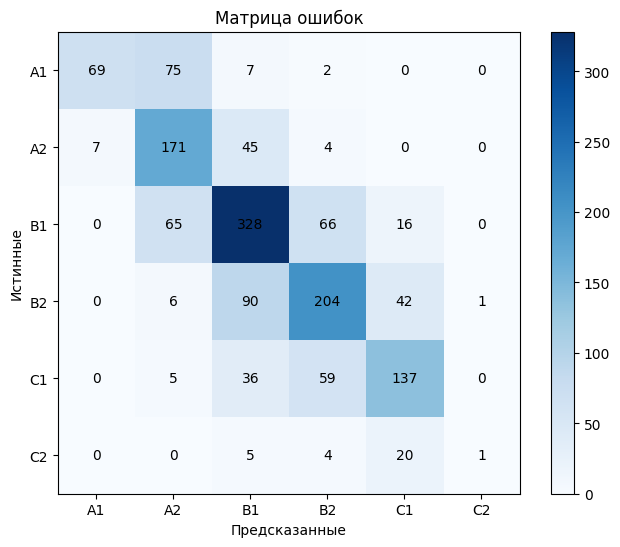

In [14]:
visualize_cm(true_labels, predictions)

# Аугментация В2

In [15]:
c2 = pd.read_csv('c2_from_b2_augmented_llama3.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.056000,0.962216
2,0.558800,1.089275
3,0.138800,1.443604


Обучение завершено за 327.85 секунд (0:05:27)


In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time) 

Accuracy: 0.6177
F1 Micro: 0.6177
F1 Macro: 0.5279
F1 Weighted: 0.6112
MAE: 0.4567
              precision    recall  f1-score   support

           1       0.92      0.50      0.65       153
           2       0.54      0.74      0.62       227
           3       0.61      0.71      0.66       475
           4       0.62      0.56      0.59       343
           5       0.63      0.55      0.59       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.64      0.62      0.61      1465



0.6177
0.6177
0.5279
0.6112
0.4567
327.85


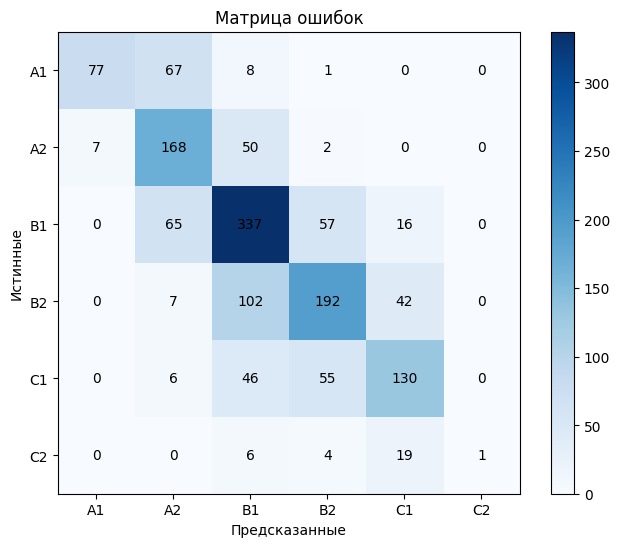

In [17]:
visualize_cm(true_labels, predictions)

# Аугментация С1

In [18]:
c2 = pd.read_csv('c2_from_c1_augmented_llama3.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.057800,0.956008
2,0.561400,1.062816
3,0.161200,1.461652


Обучение завершено за 328.10 секунд (0:05:28)


In [19]:
true_labels, predictions = predict(model, val_dataset, device, train_time) 

Accuracy: 0.6212
F1 Micro: 0.6212
F1 Macro: 0.5168
F1 Weighted: 0.6140
MAE: 0.4539
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.52      0.74      0.61       227
           3       0.63      0.71      0.66       475
           4       0.64      0.58      0.61       343
           5       0.63      0.59      0.61       237
           6       0.00      0.00      0.00        30

    accuracy                           0.62      1465
   macro avg       0.55      0.51      0.52      1465
weighted avg       0.63      0.62      0.61      1465



0.6212
0.6212
0.5168
0.6140
0.4539
328.10


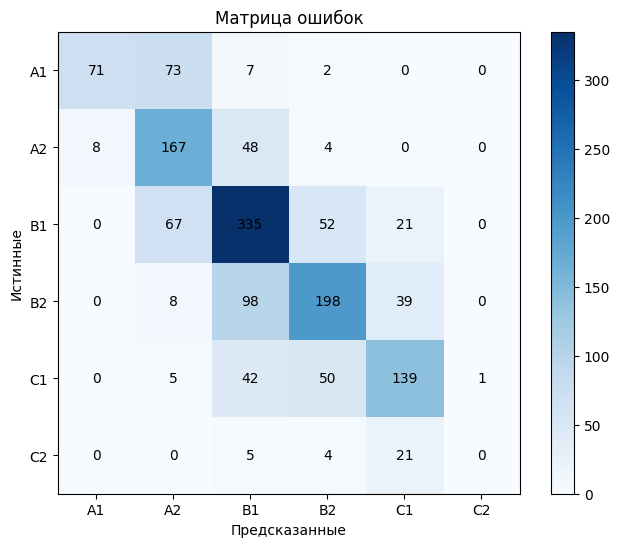

In [20]:
visualize_cm(true_labels, predictions)